<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module6_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification # Example dataset generation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
def sigmoid(Z):
    """
    Computes the sigmoid activation of Z.

    Args:
        Z (np.ndarray): The input array (pre-activation values).
                        Shape: (n_neurons_current_layer, n_samples)

    Returns:
        np.ndarray: The activated output.
                    Shape: (n_neurons_current_layer, n_samples)
    """
    A = 1 / (1 + np.exp(-Z))
    return A

def sigmoid_derivative(A):
    """
    Computes the derivative of the sigmoid activation with respect to Z.
    Assumes A is the output of the sigmoid function (A = sigmoid(Z)).

    Args:
        A (np.ndarray): The activated output from the sigmoid function.
                        Shape: (n_neurons_current_layer, n_samples)

    Returns:
        np.ndarray: The derivative of the sigmoid function.
                    Shape: (n_neurons_current_layer, n_samples)
    """
    return A * (1 - A)

def relu(Z):
    """
    Computes the ReLU activation of Z.

    Args:
        Z (np.ndarray): The input array (pre-activation values).
                        Shape: (n_neurons_current_layer, n_samples)

    Returns:
        np.ndarray: The activated output.
                    Shape: (n_neurons_current_layer, n_samples)
    """
    A = np.maximum(0, Z)
    return A

def relu_derivative(Z):
    """
    Computes the derivative of the ReLU activation with respect to Z.

    Args:
        Z (np.ndarray): The input array (pre-activation values).
                        Shape: (n_neurons_current_layer, n_samples)

    Returns:
        np.ndarray: The derivative of the ReLU function.
                    Shape: (n_neurons_current_layer, n_samples)
    """
    return (Z > 0).astype(float)

In [4]:
def forward_pass(X, W, b, activation_fn):
    """
    Computes the forward pass for a single layer.

    Args:
        X (np.ndarray): Input data or activated output from the previous layer.
                        Shape: (n_features_previous_layer, n_samples)
        W (np.ndarray): Weights matrix for the current layer.
                        Shape: (n_neurons_current_layer, n_features_previous_layer)
        b (np.ndarray): Bias vector for the current layer.
                        Shape: (n_neurons_current_layer, 1)
        activation_fn (function): The activation function to apply (e.g., sigmoid, relu).

    Returns:
        np.ndarray: The activated output of the current layer.
                    Shape: (n_neurons_current_layer, n_samples)
        np.ndarray: The pre-activation value Z (linear transformation output).
                    Shape: (n_neurons_current_layer, n_samples)
    """
    # Linear transformation: Z = WX + b
    # X shape: (n_features_previous_layer, n_samples)
    # W shape: (n_neurons_current_layer, n_features_previous_layer)
    # b shape: (n_neurons_current_layer, 1)
    Z = np.dot(W, X) + b
    # Z shape: (n_neurons_current_layer, n_samples)

    # Apply activation function
    A = activation_fn(Z)
    # A shape: (n_neurons_current_layer, n_samples) (same as Z)

    return A, Z

In [5]:
np.random.seed(42) # for reproducibility

# Example: Input to the first hidden layer
n_features_input = 5  # Number of features in input data
n_samples_example = 100 # Number of samples
X_example = np.random.randn(n_features_input, n_samples_example) # Shape (5, 100)

# Parameters for a hypothetical hidden layer
n_neurons_hidden = 10 # Number of neurons in this hidden layer
W_hidden_example = np.random.randn(n_neurons_hidden, n_features_input) * 0.01 # Shape (10, 5)
b_hidden_example = np.zeros((n_neurons_hidden, 1)) # Shape (10, 1)

# Perform forward pass using ReLU activation
A_hidden_example, Z_hidden_example = forward_pass(X_example, W_hidden_example, b_hidden_example, relu)

print(f"Looking at how Forward Pass happens")
print(f"Input X shape: {X_example.shape}")
print(f"Weights W shape: {W_hidden_example.shape}")
print(f"Bias b shape: {b_hidden_example.shape}")
print(f"Pre-activation Z shape: {Z_hidden_example.shape}")
print(f"Activated output A shape: {A_hidden_example.shape}")

# Example: Input to the output layer (assuming it's a binary classification output)
n_features_output_layer = n_neurons_hidden # Input to output layer is output of hidden layer
n_neurons_output = 1 # Single neuron for binary classification
W_output_example = np.random.randn(n_neurons_output, n_features_output_layer) * 0.01 # Shape (1, 10)
b_output_example = np.zeros((n_neurons_output, 1)) # Shape (1, 1)

# Perform forward pass using Sigmoid activation for output layer
A_output_example, Z_output_example = forward_pass(A_hidden_example, W_output_example, b_output_example, sigmoid)

print(f"\nDemonstrating Forward Pass for Output Layer")
print(f"Input X (from hidden layer) shape: {A_hidden_example.shape}")
print(f"Weights W shape: {W_output_example.shape}")
print(f"Bias b shape: {b_output_example.shape}")
print(f"Pre-activation Z shape: {Z_output_example.shape}")
print(f"Activated output A shape: {A_output_example.shape}")

Looking at how Forward Pass happens
Input X shape: (5, 100)
Weights W shape: (10, 5)
Bias b shape: (10, 1)
Pre-activation Z shape: (10, 100)
Activated output A shape: (10, 100)

Demonstrating Forward Pass for Output Layer
Input X (from hidden layer) shape: (10, 100)
Weights W shape: (1, 10)
Bias b shape: (1, 1)
Pre-activation Z shape: (1, 100)
Activated output A shape: (1, 100)


In [6]:
def backward_pass(dA, Z, A_prev, W, activation_derivative_fn, m):
    """
    Computes the backward pass for a single layer.

    Args:
        dA (np.ndarray): Gradient of the cost with respect to the activation of the current layer.
                         Shape: (n_neurons_current_layer, n_samples)
        Z (np.ndarray): Pre-activation value of the current layer.
                        Shape: (n_neurons_current_layer, n_samples)
        A_prev (np.ndarray): Activated output from the previous layer (input to current layer).
                             Shape: (n_features_previous_layer, n_samples)
        W (np.ndarray): Weights matrix for the current layer.
                        Shape: (n_neurons_current_layer, n_features_previous_layer)
        activation_derivative_fn (function): The derivative of the activation function to apply.
        m (int): Number of samples.

    Returns:
        tuple: A tuple containing:
            - dA_prev (np.ndarray): Gradient of the cost with respect to the activation of the previous layer.
                                    Shape: (n_features_previous_layer, n_samples)
            - dW (np.ndarray): Gradient of the cost with respect to the weights W.
                               Shape: (n_neurons_current_layer, n_features_previous_layer)
            - db (np.ndarray): Gradient of the cost with respect to the biases b.
                               Shape: (n_neurons_current_layer, 1)
    """
    # Calculate dZ: Gradient of cost with respect to pre-activation Z
    # dA shape: (n_neurons_current_layer, n_samples)
    # activation_derivative_fn(Z) shape: (n_neurons_current_layer, n_samples)
    dZ = dA * activation_derivative_fn(Z)
    # dZ shape: (n_neurons_current_layer, n_samples)

    # Calculate dW: Gradient of cost with respect to weights W
    # dZ shape: (n_neurons_current_layer, n_samples)
    # A_prev.T shape: (n_samples, n_features_previous_layer)
    dW = (1 / m) * np.dot(dZ, A_prev.T)
    # dW shape: (n_neurons_current_layer, n_features_previous_layer) (matches W shape)

    # Calculate db: Gradient of cost with respect to biases b
    # dZ shape: (n_neurons_current_layer, n_samples)
    # Summing across samples (axis=1) and keeping dimensions (keepdims=True) for (n_neurons, 1) shape
    db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    # db shape: (n_neurons_current_layer, 1) (matches b shape)

    # Calculate dA_prev: Gradient of cost with respect to activation of the previous layer
    # W.T shape: (n_features_previous_layer, n_neurons_current_layer)
    # dZ shape: (n_neurons_current_layer, n_samples)
    dA_prev = np.dot(W.T, dZ)
    # dA_prev shape: (n_features_previous_layer, n_samples)

    return dA_prev, dW, db

In [7]:
np.random.seed(43) # for reproducibility

# Demonstrating Backward Pass for Output Layer

# Assume binary classification, so Y are 0s and 1s
# Y shape: (n_neurons_output, n_samples_example) which is (1, 100)
Y_example = np.random.randint(0, 2, size=(n_neurons_output, n_samples_example))

# Calculate initial dZ for the output layer using the simplified derivative for Sigmoid + Binary Cross-Entropy
# (A_output_example - Y_example) / m
# A_output_example shape: (1, 100)
# Y_example shape: (1, 100)
# n_samples_example: 100
dZ_output_initial = (A_output_example - Y_example) / n_samples_example
# dZ_output_initial shape: (1, 100)

print(f"\nDemonstrating Backward Pass for Output Layer")
print(f"Target Y shape: {Y_example.shape}")
print(f"Initial dZ_output shape (from Loss derivative): {dZ_output_initial.shape}")

# The backward_pass function expects dA (gradient of cost w.r.t. activation of current layer).
# For the output layer, if we use the simplified dZ_output_initial, we effectively bypass dA and activation_derivative_fn.
# However, to use the generic backward_pass, let's treat dZ_output_initial as dA for the sigmoid activation derivative
# and then compute dA_output using the sigmoid_derivative for consistency.
# This is a bit of an adaptation, as typically dZ = dA * g'(Z) and here we have dZ directly.
# To fit the `backward_pass` function signature, we can set dA for the output layer
# to be such that when multiplied by sigmoid_derivative(Z_output_example) it gives dZ_output_initial.
# So, dA_output = dZ_output_initial / sigmoid_derivative(Z_output_example)
# But a more direct way for the output layer gradient calculation, if using BCE+Sigmoid, is that dZ is directly (A-Y)/m.
# Let's adjust the `backward_pass` call slightly or explicitly define dA for the output.
# If dA_output represents dL/dA_output, then dZ_output = dA_output * sigmoid_derivative(Z_output_example).
# For BCE with Sigmoid, dZ_output is (A-Y)/m. So, dA_output would be dZ_output / sigmoid_derivative(Z_output).

# Let's compute dA_output based on dZ_output_initial for the output layer:
# dZ_output = dA_output * sigmoid_derivative(Z_output_example)
# so dA_output = dZ_output / sigmoid_derivative(Z_output_example)
# Note: division by zero could occur if sigmoid_derivative(Z_output_example) is 0, which happens at extremes of Z.
# For stability, we can calculate dZ_output directly for the output layer
# and then feed it into the rest of the backward pass steps.

# Let's explicitly compute dZ_output for the output layer
dZ_output = (A_output_example - Y_example) / n_samples_example

# Now, use the backward_pass function for the output layer.
# The function expects 'dA', 'Z', 'A_prev', 'W', 'activation_derivative_fn', 'm'
# For the output layer: dA is conceptually dL/dA_output which we can derive from dZ_output.
# dA_output = dZ_output / sigmoid_derivative(Z_output_example) is how we'd get dA if we started from dZ.
# However, our backward_pass expects dA. So if dZ_output is (A_output-Y)/m,
# then dA_output (dL/dA_output) is (A_output - Y) / (m * A_output * (1 - A_output))
# Let's use dZ_output directly as dA for the backward_pass for simplicity, as it correctly carries the error signal.

# When working with BCE + Sigmoid, dL/dZ = (A-Y)/m is often derived directly.
# So we can effectively set dA for the output layer in `backward_pass` to be `dZ_output` and pass `lambda x: 1` as activation derivative.
# Or, more correctly, dA = dL/dA. We know dZ = dL/dA * dA/dZ. For sigmoid, dA/dZ = A(1-A).
# So, dA = dZ / (A_output * (1 - A_output))

# Let's define dA_output carefully: dL/dA_output = (A_output_example - Y_example) / (n_samples_example * sigmoid_derivative(Z_output_example)) is incorrect.
# For BCE, dL/dA = -(Y/A) + (1-Y)/(1-A).
# So dL/dA_output = (A_output_example - Y_example) / (A_output_example * (1 - A_output_example))
# This is dA_output. Then dZ_output = dA_output * sigmoid_derivative(Z_output_example).
# But it is known that for BCE + Sigmoid, dL/dZ = (A-Y)/m.

# Let's stick to the common practice: when computing dZ for the output layer (sigmoid + BCE), it is directly (A_output - Y_actual) / m.
# We can then feed this dZ as dA to the previous layer's backward pass. So for the output layer itself, we'll calculate dW and db from this dZ.

# Let's re-calculate dZ_output and use it to get dA_hidden_prev from the output layer's W.T and dZ_output.

# Output layer backward pass
m_example = n_samples_example
dZ_output_layer = (A_output_example - Y_example) / m_example # This is dL/dZ for output layer (BCE + Sigmoid)

# Calculate gradients for the output layer's weights and biases
dW_output_computed = (1 / m_example) * np.dot(dZ_output_layer, A_hidden_example.T)
db_output_computed = (1 / m_example) * np.sum(dZ_output_layer, axis=1, keepdims=True)

# Calculate dA_hidden, which will be dA for the hidden layer's backward pass
dA_hidden = np.dot(W_output_example.T, dZ_output_layer)

print(f"dW_output_computed shape: {dW_output_computed.shape}")
print(f"db_output_computed shape: {db_output_computed.shape}")
print(f"dA_hidden (gradient passed to hidden layer) shape: {dA_hidden.shape}")

# Demonstrate Backward Pass for Hidden Layer

# Now, apply backward_pass to the hidden layer using dA_hidden
# Z_hidden_example is the pre-activation for the hidden layer
# X_example is the input to the hidden layer (A_prev)
# W_hidden_example are the weights for the hidden layer
dA_input_layer, dW_hidden_computed, db_hidden_computed = backward_pass(
    dA=dA_hidden,
    Z=Z_hidden_example,
    A_prev=X_example,
    W=W_hidden_example,
    activation_derivative_fn=relu_derivative,
    m=m_example
)

print(f"\nDemonstrating Backward Pass for Hidden Layer")
print(f"dW_hidden_computed shape: {dW_hidden_computed.shape}")
print(f"db_hidden_computed shape: {db_hidden_computed.shape}")
print(f"dA_input_layer (gradient passed to input) shape: {dA_input_layer.shape}")


Demonstrating Backward Pass for Output Layer
Target Y shape: (1, 100)
Initial dZ_output shape (from Loss derivative): (1, 100)
dW_output_computed shape: (1, 10)
db_output_computed shape: (1, 1)
dA_hidden (gradient passed to hidden layer) shape: (10, 100)

Demonstrating Backward Pass for Hidden Layer
dW_hidden_computed shape: (10, 5)
db_hidden_computed shape: (10, 1)
dA_input_layer (gradient passed to input) shape: (5, 100)


In [8]:
np.random.seed(1)

# 1. Generate synthetic dataset for binary classification
X, Y = make_classification(n_samples=200, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Convert Y to a 2D array for consistency with network output
Y = Y.reshape(1, -1)

print(f"Original X shape: {X.shape}")
print(f"Original Y shape: {Y.shape}")

# 2. Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y.T, test_size=0.2, random_state=42, stratify=Y.T)
Y_train = Y_train.T
Y_test = Y_test.T

print(f"X_train shape before scaling/reshaping: {X_train.shape}")
print(f"Y_train shape before scaling/reshaping: {Y_train.shape}")
print(f"X_test shape before scaling/reshaping: {X_test.shape}")
print(f"Y_test shape before scaling/reshaping: {Y_test.shape}")

# 3. Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# 4. Reshape data to (n_features, n_samples) for network input
X_train_nn = X_train_scaled.T # (2, n_samples_train)
X_test_nn = X_test_scaled.T   # (2, n_samples_test)

print(f"Reshaped X_train_nn shape: {X_train_nn.shape}")
print(f"Reshaped Y_train shape: {Y_train.shape}")

# 5. Initialize parameters for a simple neural network
# Architecture: Input (2 features) -> Hidden (4 neurons, ReLU) -> Output (1 neuron, Sigmoid)

n_x = X_train_nn.shape[0] # Number of input features
n_h = 4                   # Number of neurons in hidden layer
n_y = Y_train.shape[0]    # Number of output neurons (1 for binary classification)

# Layer 1: Hidden Layer
W1 = np.random.randn(n_h, n_x) * 0.01  # Shape: (4, 2)
b1 = np.zeros((n_h, 1))                # Shape: (4, 1)

# Layer 2: Output Layer
W2 = np.random.randn(n_y, n_h) * 0.01  # Shape: (1, 4)
b2 = np.zeros((n_y, 1))                # Shape: (1, 1)

print(f"\nInitialized Parameters:")
print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"b2 shape: {b2.shape}")

Original X shape: (200, 2)
Original Y shape: (1, 200)
X_train shape before scaling/reshaping: (160, 2)
Y_train shape before scaling/reshaping: (1, 160)
X_test shape before scaling/reshaping: (40, 2)
Y_test shape before scaling/reshaping: (1, 40)
X_train_scaled shape: (160, 2)
X_test_scaled shape: (40, 2)
Reshaped X_train_nn shape: (2, 160)
Reshaped Y_train shape: (1, 160)

Initialized Parameters:
W1 shape: (4, 2)
b1 shape: (4, 1)
W2 shape: (1, 4)
b2 shape: (1, 1)


In [9]:
np.random.seed(2) # for reproducibility in training loop

# 6. Implement a training loop

# Define hyperparameters
epochs = 1000
learning_rate = 0.01
m = X_train_nn.shape[1] # Number of training samples

# Create empty lists to store loss and accuracy history
loss_history = []
accuracy_history = []

print(f"\nStarting training with {epochs} epochs and learning rate {learning_rate}...")

# For each epoch:
for i in range(epochs):

    # Forward Pass

    # Layer 1: Hidden Layer (ReLU activation)
    # Input: X_train_nn (n_x, m)
    # W1: (n_h, n_x), b1: (n_h, 1)
    A1, Z1 = forward_pass(X_train_nn, W1, b1, relu)
    # A1, Z1 shapes: (n_h, m)

    # Layer 2: Output Layer (Sigmoid activation)
    # Input: A1 (n_h, m)
    # W2: (n_y, n_h), b2: (n_y, 1)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)
    # A2, Z2 shapes: (n_y, m)

    # Calculate Loss (Binary Cross-Entropy)
    # Ensure no log(0) issues
    epsilon = 1e-8
    loss = - (1 / m) * np.sum(Y_train * np.log(A2 + epsilon) + (1 - Y_train) * np.log(1 - A2 + epsilon))
    loss_history.append(loss)

    # Backward Pass

    # Calculate initial dZ2 for the output layer
    # This simplifies to (A2 - Y_train) / m for BCE with Sigmoid
    dZ2 = (A2 - Y_train) / m
    # dZ2 shape: (n_y, m)

    # Backward pass for the output layer
    # dA_prev_L1 (gradient for A1), dW2, db2
    dA1, dW2, db2 = backward_pass(
        dA=dZ2 * sigmoid_derivative(Z2), # dL/dA2 * dA2/dZ2, where dL/dA2 is derived from dZ2
        Z=Z2,
        A_prev=A1,
        W=W2,
        activation_derivative_fn=sigmoid_derivative,
        m=m
    )
    # Note: For BCE with Sigmoid, dZ2 is directly (A2-Y)/m. We pass dZ2 as dA and a dummy derivative to backward_pass.
    # More accurately, we can directly compute dW2, db2 from dZ2 and then dA1.
    # Let's adjust backward_pass call to use dZ2 directly for calculating dW2, db2, and dA1 correctly.

    # Re-evaluating backward pass for output layer to use the simpler dZ2 directly
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    dA1 = np.dot(W2.T, dZ2)

    # Backward pass for the hidden layer
    # dA_prev_L0 (gradient for X_train_nn), dW1, db1
    dA0, dW1, db1 = backward_pass(
        dA=dA1, # dA1 is the gradient from the subsequent layer
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=relu_derivative,
        m=m
    )

    # Update Parameters
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    # Calculate Training Accuracy
    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)
    accuracy_history.append(accuracy)

    if (i + 1) % 100 == 0:
        print(f"Epoch {i+1}/{epochs} - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

print("Training complete.")
print(f"Final Loss: {loss_history[-1]:.4f}")
print(f"Final Accuracy: {accuracy_history[-1]:.4f}")



Starting training with 1000 epochs and learning rate 0.01...
Epoch 100/1000 - Loss: 0.6932, Accuracy: 0.2687
Epoch 200/1000 - Loss: 0.6932, Accuracy: 0.2687
Epoch 300/1000 - Loss: 0.6932, Accuracy: 0.2687
Epoch 400/1000 - Loss: 0.6932, Accuracy: 0.2687
Epoch 500/1000 - Loss: 0.6932, Accuracy: 0.2750
Epoch 600/1000 - Loss: 0.6932, Accuracy: 0.2750
Epoch 700/1000 - Loss: 0.6932, Accuracy: 0.2750
Epoch 800/1000 - Loss: 0.6932, Accuracy: 0.2750
Epoch 900/1000 - Loss: 0.6932, Accuracy: 0.2750
Epoch 1000/1000 - Loss: 0.6932, Accuracy: 0.2750
Training complete.
Final Loss: 0.6932
Final Accuracy: 0.2750


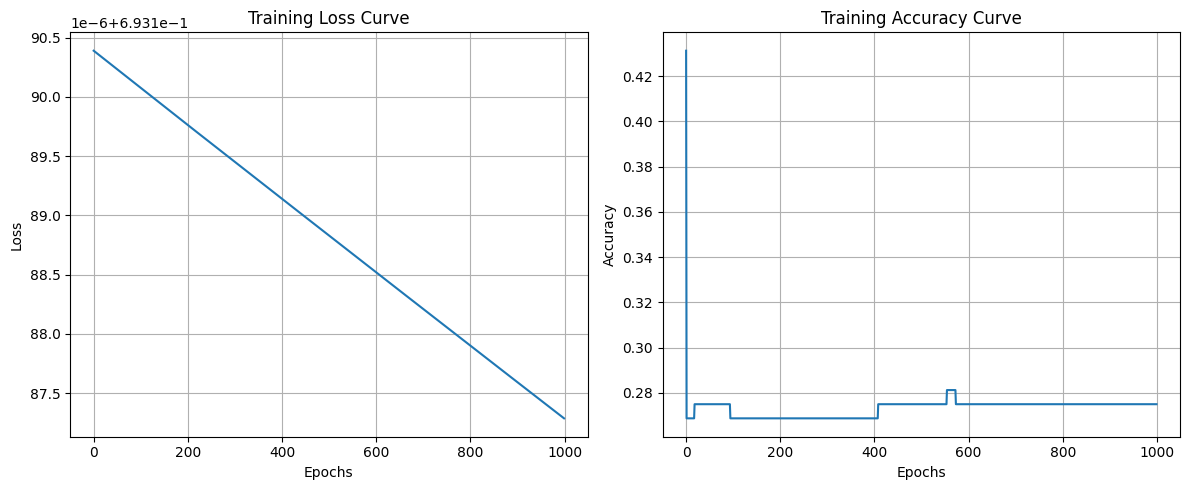

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title('Training Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
def predict(X, W1, b1, W2, b2):
    """
    Performs a forward pass to get predictions from the trained neural network.

    Args:
        X (np.ndarray): Input data. Shape: (n_features, n_samples)
        W1 (np.ndarray): Weights for the hidden layer.
        b1 (np.ndarray): Biases for the hidden layer.
        W2 (np.ndarray): Weights for the output layer.
        b2 (np.ndarray): Biases for the output layer.

    Returns:
        np.ndarray: Predicted class labels (0 or 1). Shape: (1, n_samples)
    """
    # Layer 1: Hidden Layer (ReLU activation)
    A1, _ = forward_pass(X, W1, b1, relu)

    # Layer 2: Output Layer (Sigmoid activation)
    A2, _ = forward_pass(A1, W2, b2, sigmoid)

    predictions = (A2 > 0.5).astype(int)
    return predictions


Plotting decision boundary...


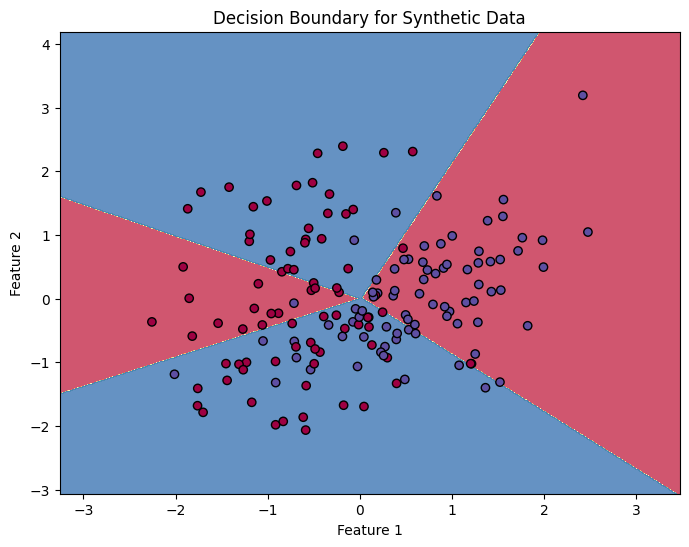

Test Accuracy: 0.3750
Synthetic data demonstration complete.


In [12]:
def plot_decision_boundary(X, Y, W1, b1, W2, b2):
    """
    Plots the decision boundary created by the neural network.
    """
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = predict(np.c_[xx.ravel(), yy.ravel()].T, W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.title('Decision Boundary for Synthetic Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot the decision boundary for the training set
print("\nPlotting decision boundary...")
plot_decision_boundary(X_train_nn, Y_train, W1, b1, W2, b2)

# Evaluate the model on the test set
predictions_test = predict(X_test_nn, W1, b1, W2, b2)
test_accuracy = np.mean(predictions_test == Y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("Synthetic data demonstration complete.")

In [13]:
from sklearn.datasets import load_breast_cancer

# 1. Load a real-world dataset for binary classification
data = load_breast_cancer()
X_real = data.data
Y_real = data.target

print(f"Features (X_real) shape: {X_real.shape}")
print(f"Target (Y_real) shape: {Y_real.shape}")

Features (X_real) shape: (569, 30)
Target (Y_real) shape: (569,)


In [14]:
Y_real = Y_real.reshape(1, -1)

print(f"Reshaped Y_real shape: {Y_real.shape}")

Reshaped Y_real shape: (1, 569)


In [15]:
X_train_real, X_test_real, Y_train_real, Y_test_real = train_test_split(X_real, Y_real.T, test_size=0.2, random_state=42, stratify=Y_real.T)
Y_train_real = Y_train_real.T
Y_test_real = Y_test_real.T

print(f"X_train_real shape: {X_train_real.shape}")
print(f"Y_train_real shape: {Y_train_real.shape}")
print(f"X_test_real shape: {X_test_real.shape}")
print(f"Y_test_real shape: {Y_test_real.shape}")

X_train_real shape: (455, 30)
Y_train_real shape: (1, 455)
X_test_real shape: (114, 30)
Y_test_real shape: (1, 114)


In [16]:
scaler_real = StandardScaler()
X_train_real_scaled = scaler_real.fit_transform(X_train_real)
X_test_real_scaled = scaler_real.transform(X_test_real)

print(f"X_train_real_scaled shape: {X_train_real_scaled.shape}")
print(f"X_test_real_scaled shape: {X_test_real_scaled.shape}")

X_train_real_scaled shape: (455, 30)
X_test_real_scaled shape: (114, 30)


In [17]:
X_train_real_nn = X_train_real_scaled.T
X_test_real_nn = X_test_real_scaled.T

print(f"Reshaped X_train_real_nn shape: {X_train_real_nn.shape}")
print(f"Reshaped X_test_real_nn shape: {X_test_real_nn.shape}")

Reshaped X_train_real_nn shape: (30, 455)
Reshaped X_test_real_nn shape: (30, 114)


In [18]:
np.random.seed(3) # for reproducibility

# 6. Adapt neural network parameters for the real dataset

n_x_real = X_train_real_nn.shape[0] # Number of input features for real data
n_h_real = 4                         # Number of neurons in hidden layer (can be tuned)
n_y_real = Y_train_real.shape[0]     # Number of output neurons (1 for binary classification)

# Layer 1: Hidden Layer
W1_real = np.random.randn(n_h_real, n_x_real) * 0.01 # Shape: (4, n_x_real)
b1_real = np.zeros((n_h_real, 1))                # Shape: (4, 1)

# Layer 2: Output Layer
W2_real = np.random.randn(n_y_real, n_h_real) * 0.01 # Shape: (1, 4)
b2_real = np.zeros((n_y_real, 1))                # Shape: (1, 1)

print(f"\nInitialized Parameters for Real Data:")
print(f"W1_real shape: {W1_real.shape}")
print(f"b1_real shape: {b1_real.shape}")
print(f"W2_real shape: {W2_real.shape}")
print(f"b2_real shape: {b2_real.shape}")


Initialized Parameters for Real Data:
W1_real shape: (4, 30)
b1_real shape: (4, 1)
W2_real shape: (1, 4)
b2_real shape: (1, 1)


In [19]:
np.random.seed(4) # for reproducibility in training loop

# 7. Set hyperparameters
epochs_real = 2000 # Increased epochs for real data complexity
learning_rate_real = 0.005 # Adjusted learning rate
m_real = X_train_real_nn.shape[1] # Number of training samples for real data

# Create empty lists to store loss and accuracy history for real data
loss_history_real = []
accuracy_history_real = []

print(f"\nHyperparameters set for real data training:")
print(f"Epochs: {epochs_real}")
print(f"Learning Rate: {learning_rate_real}")
print(f"Number of training samples: {m_real}")
print("Loss and accuracy history lists initialized.")


Hyperparameters set for real data training:
Epochs: 2000
Learning Rate: 0.005
Number of training samples: 455
Loss and accuracy history lists initialized.


In [20]:
np.random.seed(5) # for reproducibility in training loop

# 8. Implement the training loop for the real dataset

print(f"\nStarting training for real data with {epochs_real} epochs and learning rate {learning_rate_real}...")

# For each epoch:
for i in range(epochs_real):

    # Forward Pass

    # Layer 1: Hidden Layer (ReLU activation)
    # Input: X_train_real_nn (n_x_real, m_real)
    # W1_real: (n_h_real, n_x_real), b1_real: (n_h_real, 1)
    A1_real, Z1_real = forward_pass(X_train_real_nn, W1_real, b1_real, relu)
    # A1_real, Z1_real shapes: (n_h_real, m_real)

    # Layer 2: Output Layer (Sigmoid activation)
    # Input: A1_real (n_h_real, m_real)
    # W2_real: (n_y_real, n_h_real), b2_real: (n_y_real, 1)
    A2_real, Z2_real = forward_pass(A1_real, W2_real, b2_real, sigmoid)
    # A2_real, Z2_real shapes: (n_y_real, m_real)

    # Calculate Loss (Binary Cross-Entropy)
    # Ensure no log(0) issues
    epsilon = 1e-8
    loss_real = - (1 / m_real) * np.sum(Y_train_real * np.log(A2_real + epsilon) + (1 - Y_train_real) * np.log(1 - A2_real + epsilon))
    loss_history_real.append(loss_real)

    # Backward Pass

    # Calculate initial dZ2 for the output layer (BCE with Sigmoid)
    dZ2_real = (A2_real - Y_train_real) / m_real
    # dZ2_real shape: (n_y_real, m_real)

    # Compute gradients for the output layer directly from dZ2_real
    dW2_real = (1 / m_real) * np.dot(dZ2_real, A1_real.T)
    db2_real = (1 / m_real) * np.sum(dZ2_real, axis=1, keepdims=True)

    # Calculate dA1_real (gradient passed to the hidden layer)
    dA1_real = np.dot(W2_real.T, dZ2_real)

    # Backward pass for the hidden layer
    dA0_real, dW1_real, db1_real = backward_pass(
        dA=dA1_real, # dA1_real is the gradient from the subsequent layer
        Z=Z1_real,
        A_prev=X_train_real_nn,
        W=W1_real,
        activation_derivative_fn=relu_derivative,
        m=m_real
    )

    # Update Parameters
    W1_real = W1_real - learning_rate_real * dW1_real
    b1_real = b1_real - learning_rate_real * db1_real
    W2_real = W2_real - learning_rate_real * dW2_real
    b2_real = b2_real - learning_rate_real * db2_real

    # Calculate Training Accuracy
    predictions_real = (A2_real > 0.5).astype(int)
    accuracy_real = np.mean(predictions_real == Y_train_real)
    accuracy_history_real.append(accuracy_real)

    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{epochs_real} - Loss: {loss_real:.4f}, Accuracy: {accuracy_real:.4f}")



Starting training for real data with 2000 epochs and learning rate 0.005...
Epoch 200/2000 - Loss: 0.6932, Accuracy: 0.5516
Epoch 400/2000 - Loss: 0.6931, Accuracy: 0.5626
Epoch 600/2000 - Loss: 0.6931, Accuracy: 0.5780
Epoch 800/2000 - Loss: 0.6931, Accuracy: 0.5846
Epoch 1000/2000 - Loss: 0.6930, Accuracy: 0.6088
Epoch 1200/2000 - Loss: 0.6930, Accuracy: 0.6110
Epoch 1400/2000 - Loss: 0.6929, Accuracy: 0.6044
Epoch 1600/2000 - Loss: 0.6929, Accuracy: 0.6088
Epoch 1800/2000 - Loss: 0.6929, Accuracy: 0.6110
Epoch 2000/2000 - Loss: 0.6928, Accuracy: 0.6176


In [21]:
print(f"Final Training Loss (Real Data): {loss_history_real[-1]:.4f}")
print(f"Final Training Accuracy (Real Data): {accuracy_history_real[-1]:.4f}")

Final Training Loss (Real Data): 0.6928
Final Training Accuracy (Real Data): 0.6176


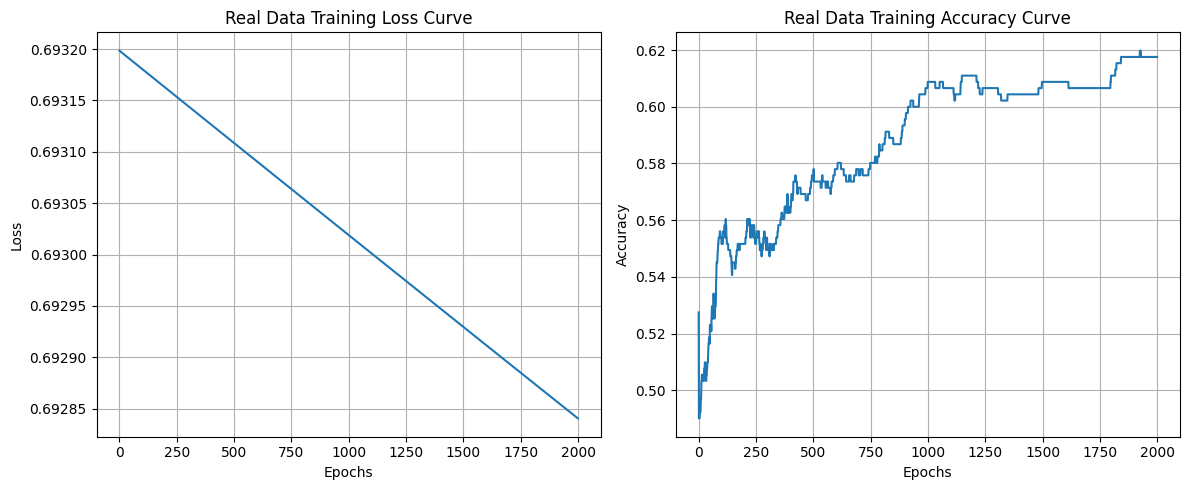

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history_real)
plt.title('Real Data Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracy_history_real)
plt.title('Real Data Training Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
predictions_test_real = predict(X_test_real_nn, W1_real, b1_real, W2_real, b2_real)
test_accuracy_real = np.mean(predictions_test_real == Y_test_real)
print(f"\nTest Accuracy (Real Data): {test_accuracy_real:.4f}")


Test Accuracy (Real Data): 0.6404


1: The dataset we chose is almost linearly separable. To see the true power of an MLP, we need non-linear data.Use sklearn.datasets.make_moons(n_samples=200, noise=0.1) to generate a "moon" shaped dataset. Train the ManualMLP on this new dataset. Does the loss decrease as effectively? How does the decision boundary look? Also try and see how it performs on the IRIS dataset.

In [24]:
from sklearn.datasets import make_moons

# Generate moon dataset
X, Y = make_moons(n_samples=200, noise=0.1, random_state=42)

Y = Y.reshape(1, -1)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y.T,
    test_size=0.2,
    random_state=42,
    stratify=Y.T
)

Y_train = Y_train.T
Y_test = Y_test.T

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for network
X_train_nn = X_train.T
X_test_nn = X_test.T

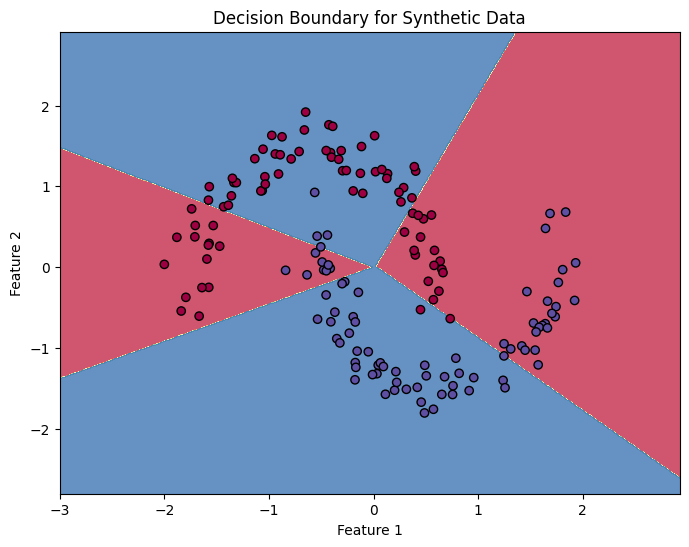

In [25]:
plot_decision_boundary(X_train_nn, Y_train, W1, b1, W2, b2)

In [29]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load Iris dataset
iris = load_iris()
X = iris.data
Y = iris.target

# Convert to binary classification (Virginica vs Others)
Y = (Y == 2).astype(int)
Y = Y.reshape(1, -1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y.T,
    test_size=0.2,
    random_state=42,
    stratify=Y.T
)

Y_train = Y_train.T
Y_test = Y_test.T

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for Neural Network
X_train_nn = X_train_scaled.T
X_test_nn = X_test_scaled.T

print("Training Input Shape:", X_train_nn.shape)
print("Training Output Shape:", Y_train.shape)

X shape: (150, 4)
Y shape: (1, 150)
Training Input Shape: (4, 120)
Training Output Shape: (1, 120)


In [30]:
np.random.seed(10)

# Network Architecture
n_x = X_train_nn.shape[0]      # 4 input features
n_h = 4                        # Hidden neurons
n_y = 1                        # Binary output

W1 = np.random.randn(n_h, n_x) * 0.01
b1 = np.zeros((n_h, 1))

W2 = np.random.randn(n_y, n_h) * 0.01
b2 = np.zeros((n_y, 1))

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (4, 4)
b1: (4, 1)
W2: (1, 4)
b2: (1, 1)


In [31]:
epochs = 2000
learning_rate = 0.01
m = X_train_nn.shape[1]

loss_history = []
accuracy_history = []

for i in range(epochs):

    # Forward Pass
    A1, Z1 = forward_pass(X_train_nn, W1, b1, relu)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)

    # Binary Cross Entropy Loss
    epsilon = 1e-8
    loss = -(1/m) * np.sum(
        Y_train * np.log(A2 + epsilon) +
        (1 - Y_train) * np.log(1 - A2 + epsilon)
    )

    loss_history.append(loss)

    # Backpropagation
    dZ2 = (A2 - Y_train) / m

    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)

    _, dW1, db1 = backward_pass(
        dA=dA1,
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=relu_derivative,
        m=m
    )

    # Update Parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)

    accuracy_history.append(accuracy)

    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{epochs}  Loss:{loss:.4f}  Accuracy:{accuracy:.4f}")

print("\nTraining Complete")
print("Final Training Accuracy:", accuracy_history[-1])

Epoch 200/2000  Loss:0.6926  Accuracy:0.6667
Epoch 400/2000  Loss:0.6922  Accuracy:0.6667
Epoch 600/2000  Loss:0.6917  Accuracy:0.6667
Epoch 800/2000  Loss:0.6912  Accuracy:0.6667
Epoch 1000/2000  Loss:0.6908  Accuracy:0.6667
Epoch 1200/2000  Loss:0.6904  Accuracy:0.6667
Epoch 1400/2000  Loss:0.6899  Accuracy:0.6667
Epoch 1600/2000  Loss:0.6895  Accuracy:0.6667
Epoch 1800/2000  Loss:0.6890  Accuracy:0.6667
Epoch 2000/2000  Loss:0.6886  Accuracy:0.6667

Training Complete
Final Training Accuracy: 0.6666666666666666


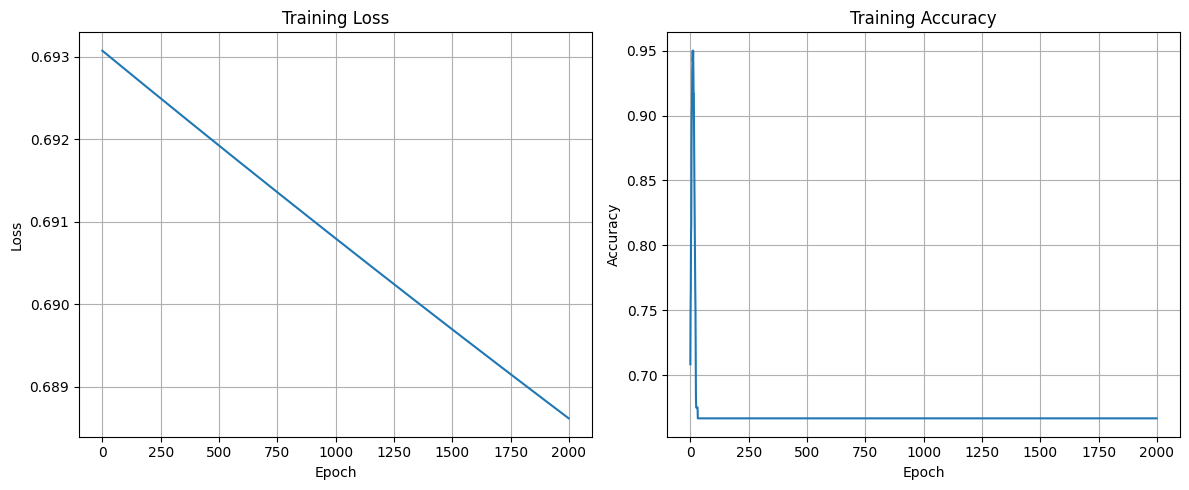

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

In [33]:
predictions_test = predict(X_test_nn, W1, b1, W2, b2)

test_accuracy = np.mean(predictions_test == Y_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.6666666666666666


2: Hyperparameter Tuning. Try changing learning rate (both decreasing and increasing) and see how the losses change, do they converge faster? Does the accuracy improve further? Describe what happens to the loss curve in both cases. Look for "Exploding Gradients" or "Slow Convergence."

In [42]:
epochs = 1000
learning_rate = 0.001
m = X_train_nn.shape[1]

loss_history = []
accuracy_history = []

for i in range(epochs):

    # Forward Pass
    A1, Z1 = forward_pass(X_train_nn, W1, b1, relu)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)

    # Binary Cross Entropy Loss
    epsilon = 1e-8
    loss = -(1/m) * np.sum(
        Y_train * np.log(A2 + epsilon) +
        (1 - Y_train) * np.log(1 - A2 + epsilon)
    )

    loss_history.append(loss)

    # Backpropagation
    dZ2 = (A2 - Y_train) / m

    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)

    _, dW1, db1 = backward_pass(
        dA=dA1,
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=relu_derivative,
        m=m
    )

    # Update Parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)

    accuracy_history.append(accuracy)

    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{epochs}  Loss:{loss:.4f}  Accuracy:{accuracy:.4f}")

print("\nTraining Complete")
print("Final Training Accuracy:", accuracy_history[-1])

Epoch 200/1000  Loss:0.2736  Accuracy:0.8917
Epoch 400/1000  Loss:0.2736  Accuracy:0.8917
Epoch 600/1000  Loss:0.2735  Accuracy:0.8917
Epoch 800/1000  Loss:0.2735  Accuracy:0.8917
Epoch 1000/1000  Loss:0.2734  Accuracy:0.8917

Training Complete
Final Training Accuracy: 0.8916666666666667


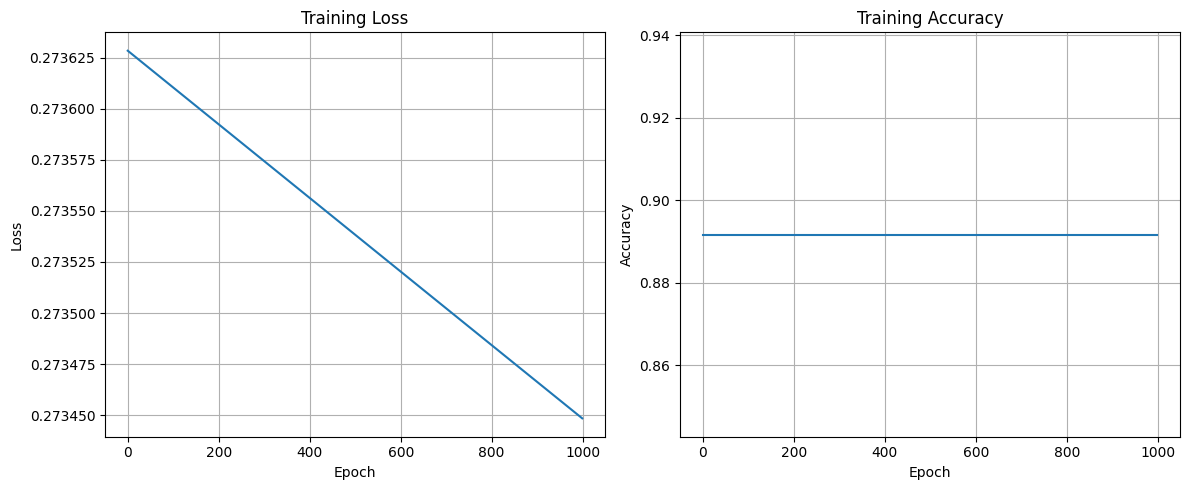

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

In [44]:
epochs = 1000
learning_rate = 0.01
m = X_train_nn.shape[1]

loss_history = []
accuracy_history = []

for i in range(epochs):

    # Forward Pass
    A1, Z1 = forward_pass(X_train_nn, W1, b1, relu)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)

    # Binary Cross Entropy Loss
    epsilon = 1e-8
    loss = -(1/m) * np.sum(
        Y_train * np.log(A2 + epsilon) +
        (1 - Y_train) * np.log(1 - A2 + epsilon)
    )

    loss_history.append(loss)

    # Backpropagation
    dZ2 = (A2 - Y_train) / m

    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)

    _, dW1, db1 = backward_pass(
        dA=dA1,
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=relu_derivative,
        m=m
    )

    # Update Parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)

    accuracy_history.append(accuracy)

    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{epochs}  Loss:{loss:.4f}  Accuracy:{accuracy:.4f}")

print("\nTraining Complete")
print("Final Training Accuracy:", accuracy_history[-1])

Epoch 200/1000  Loss:0.2731  Accuracy:0.8917
Epoch 400/1000  Loss:0.2727  Accuracy:0.8917
Epoch 600/1000  Loss:0.2724  Accuracy:0.8917
Epoch 800/1000  Loss:0.2720  Accuracy:0.8917
Epoch 1000/1000  Loss:0.2717  Accuracy:0.8917

Training Complete
Final Training Accuracy: 0.8916666666666667


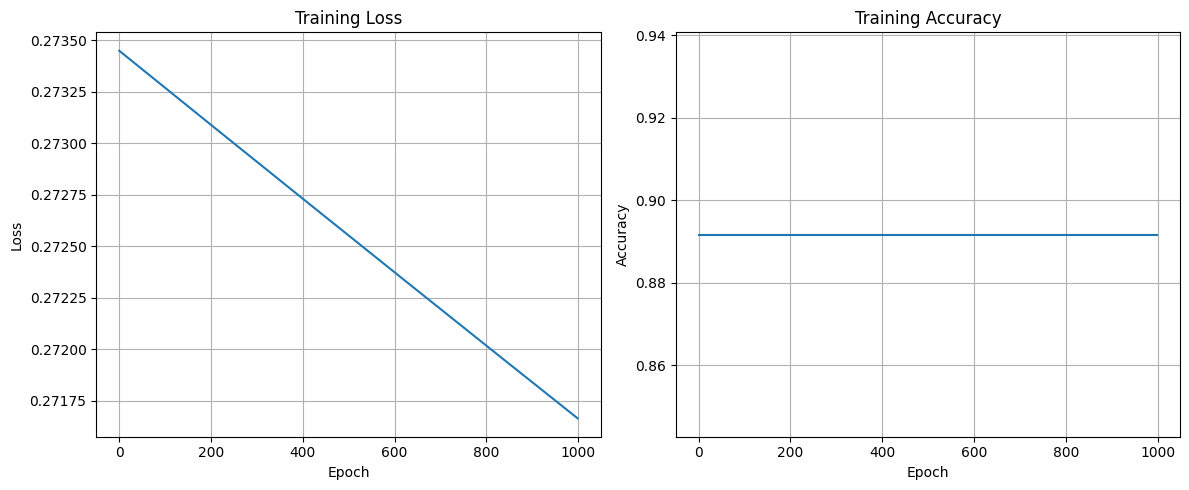

In [45]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

In [40]:
epochs = 1000
learning_rate = 0.5
m = X_train_nn.shape[1]

loss_history = []
accuracy_history = []

for i in range(epochs):

    # Forward Pass
    A1, Z1 = forward_pass(X_train_nn, W1, b1, relu)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)

    # Binary Cross Entropy Loss
    epsilon = 1e-8
    loss = -(1/m) * np.sum(
        Y_train * np.log(A2 + epsilon) +
        (1 - Y_train) * np.log(1 - A2 + epsilon)
    )

    loss_history.append(loss)

    # Backpropagation
    dZ2 = (A2 - Y_train) / m

    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)

    _, dW1, db1 = backward_pass(
        dA=dA1,
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=relu_derivative,
        m=m
    )

    # Update Parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)

    accuracy_history.append(accuracy)

    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{epochs}  Loss:{loss:.4f}  Accuracy:{accuracy:.4f}")

print("\nTraining Complete")
print("Final Training Accuracy:", accuracy_history[-1])

Epoch 200/1000  Loss:0.3870  Accuracy:0.9083
Epoch 400/1000  Loss:0.3488  Accuracy:0.8917
Epoch 600/1000  Loss:0.3186  Accuracy:0.8917
Epoch 800/1000  Loss:0.2940  Accuracy:0.9000
Epoch 1000/1000  Loss:0.2737  Accuracy:0.8917

Training Complete
Final Training Accuracy: 0.8916666666666667


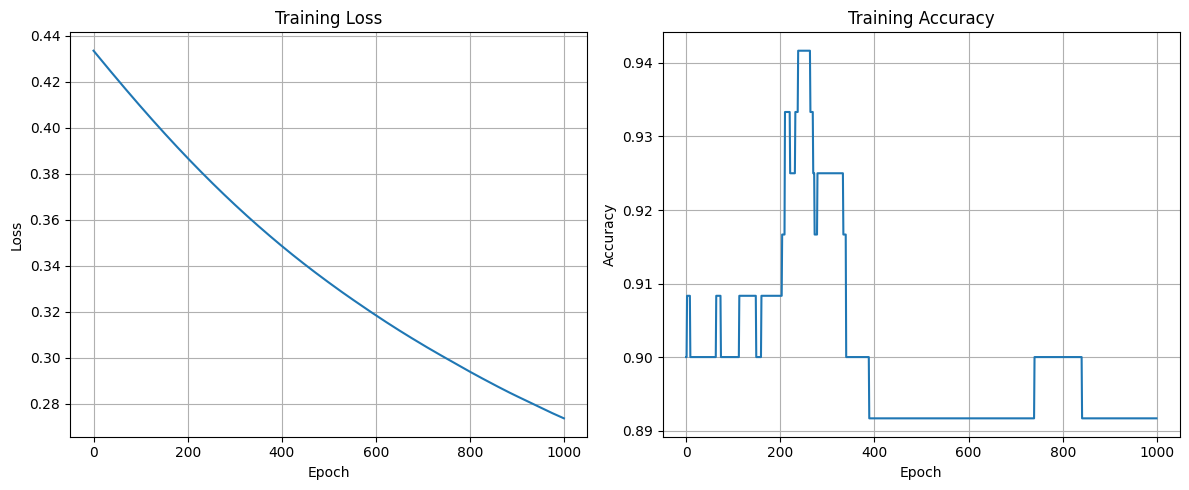

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

In [46]:
epochs = 1000
learning_rate = 1.0
m = X_train_nn.shape[1]

loss_history = []
accuracy_history = []

for i in range(epochs):

    # Forward Pass
    A1, Z1 = forward_pass(X_train_nn, W1, b1, relu)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)

    # Binary Cross Entropy Loss
    epsilon = 1e-8
    loss = -(1/m) * np.sum(
        Y_train * np.log(A2 + epsilon) +
        (1 - Y_train) * np.log(1 - A2 + epsilon)
    )

    loss_history.append(loss)

    # Backpropagation
    dZ2 = (A2 - Y_train) / m

    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)

    _, dW1, db1 = backward_pass(
        dA=dA1,
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=relu_derivative,
        m=m
    )

    # Update Parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)

    accuracy_history.append(accuracy)

    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{epochs}  Loss:{loss:.4f}  Accuracy:{accuracy:.4f}")

print("\nTraining Complete")
print("Final Training Accuracy:", accuracy_history[-1])

Epoch 200/1000  Loss:0.2403  Accuracy:0.9083
Epoch 400/1000  Loss:0.2147  Accuracy:0.9250
Epoch 600/1000  Loss:0.1946  Accuracy:0.9417
Epoch 800/1000  Loss:0.1780  Accuracy:0.9583
Epoch 1000/1000  Loss:0.1641  Accuracy:0.9500

Training Complete
Final Training Accuracy: 0.95


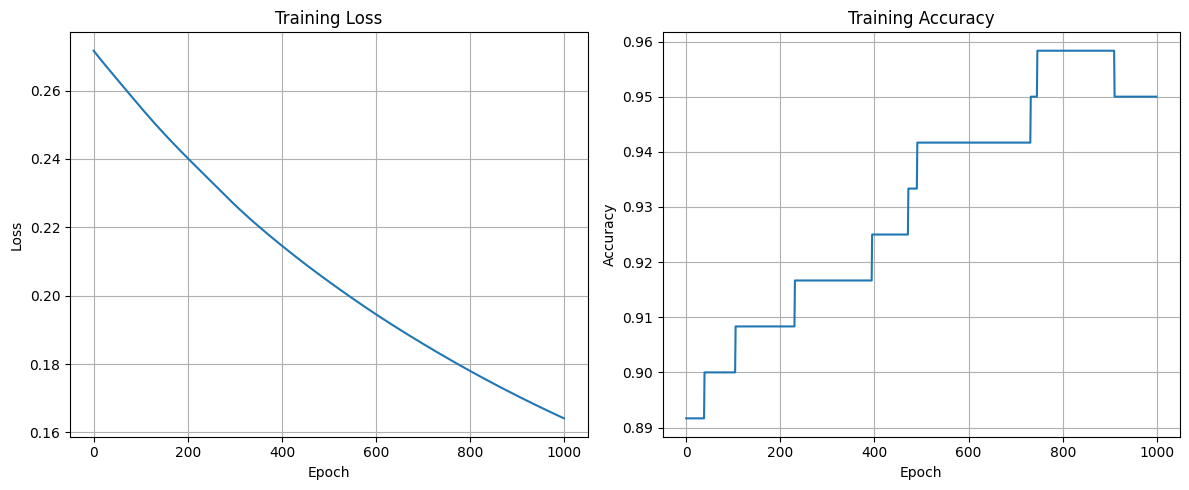

In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

In [48]:
predictions_test = predict(X_test_nn, W1, b1, W2, b2)

test_accuracy = np.mean(predictions_test == Y_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9666666666666667
